In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv(r"D:\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)

df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [13]:
df["AvgChargePerMonth"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

df["RiskLevel"] = np.where(
    df["tenure"] < 12,
    "High Risk",
    np.where(
        df["tenure"] < 24,
        "Medium Risk",
        "Low Risk"
    )
)

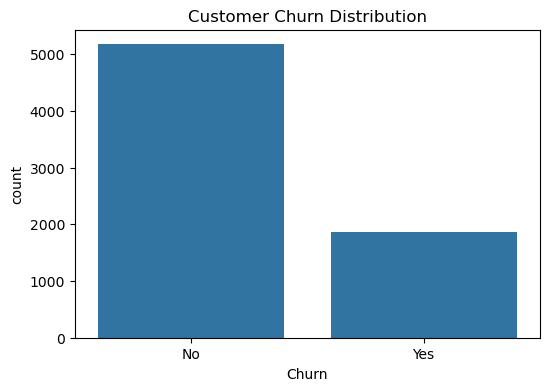

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

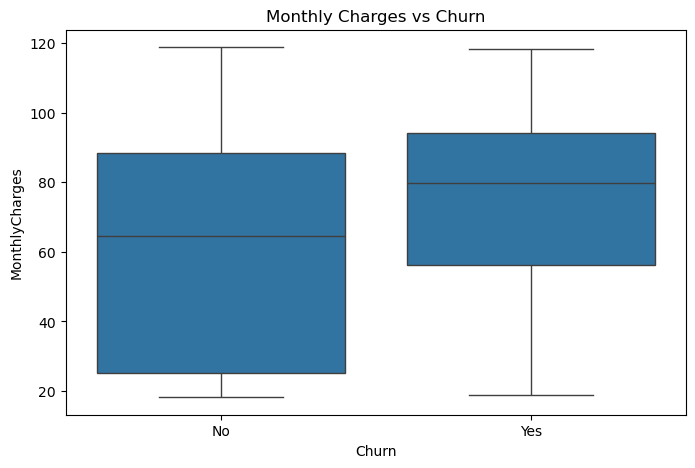

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

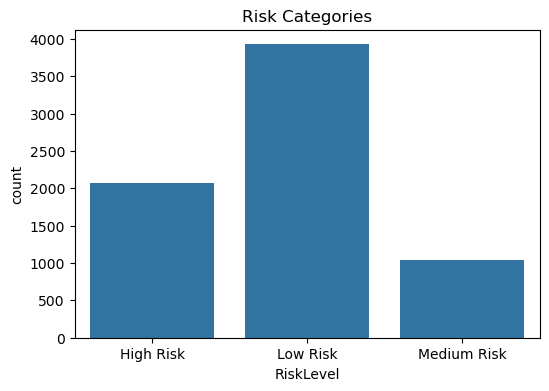

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="RiskLevel",
    data=df
)

plt.title("Risk Categories")

plt.show()

In [17]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "object":

        df[col] = le.fit_transform(
            df[col]
        )

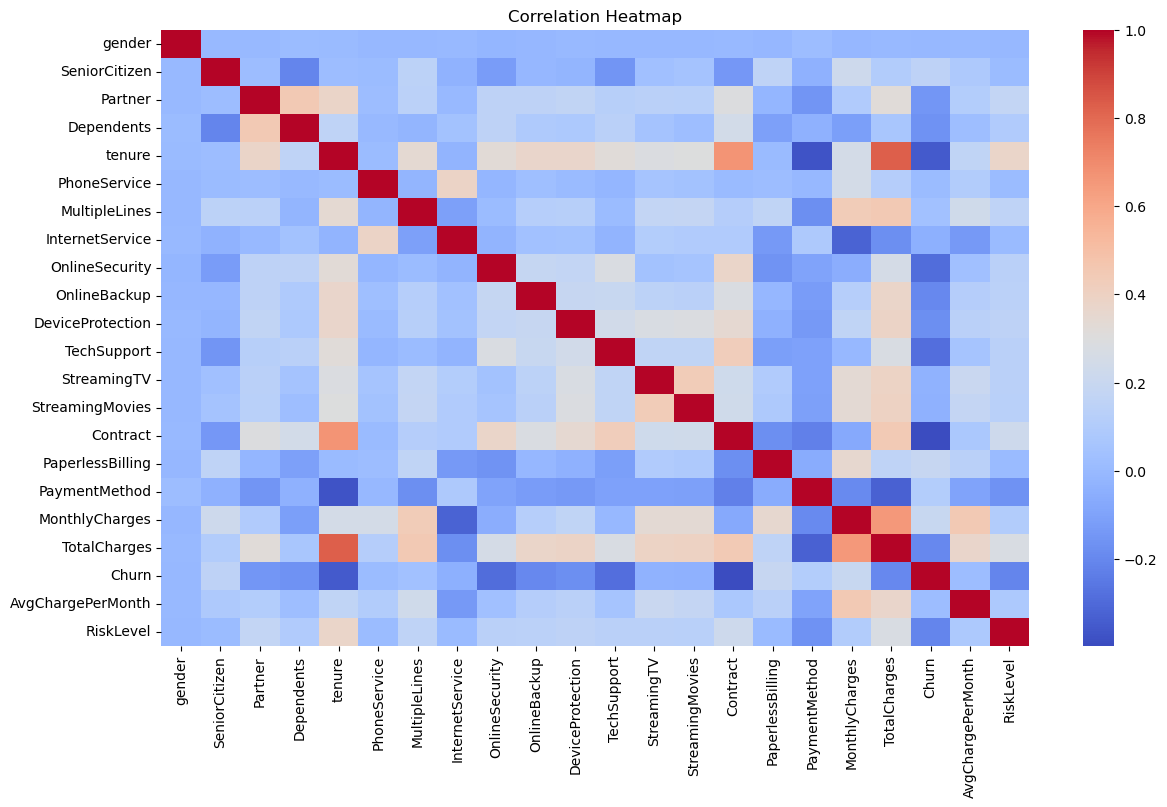

In [18]:
plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
lr = LogisticRegression(
    max_iter=2000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

acc_lr = accuracy_score(
    y_test,
    lr_pred
)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [21]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(
    X_test
)

acc_dt = accuracy_score(
    y_test,
    dt_pred
)

print(
    classification_report(
        y_test,
        dt_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1036
           1       0.63      0.62      0.62       373

    accuracy                           0.80      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

acc_rf = accuracy_score(
    y_test,
    rf_pred
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [23]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        acc_lr,
        acc_dt,
        acc_rf
    ],
    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,dt_pred),
        precision_score(y_test,rf_pred)
    ],
    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,dt_pred),
        recall_score(y_test,rf_pred)
    ],
    "F1":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,dt_pred),
        f1_score(y_test,rf_pred)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.807665,0.668874,0.541555,0.598519
1,Decision Tree,0.801278,0.625337,0.621984,0.623656
2,Random Forest,0.797729,0.667939,0.469169,0.551181


In [24]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
17,MonthlyCharges,0.145522
18,TotalCharges,0.144414
19,AvgChargePerMonth,0.136977
4,tenure,0.125542
14,Contract,0.076012
16,PaymentMethod,0.044576
8,OnlineSecurity,0.043697
11,TechSupport,0.034464
20,RiskLevel,0.030913
0,gender,0.024052


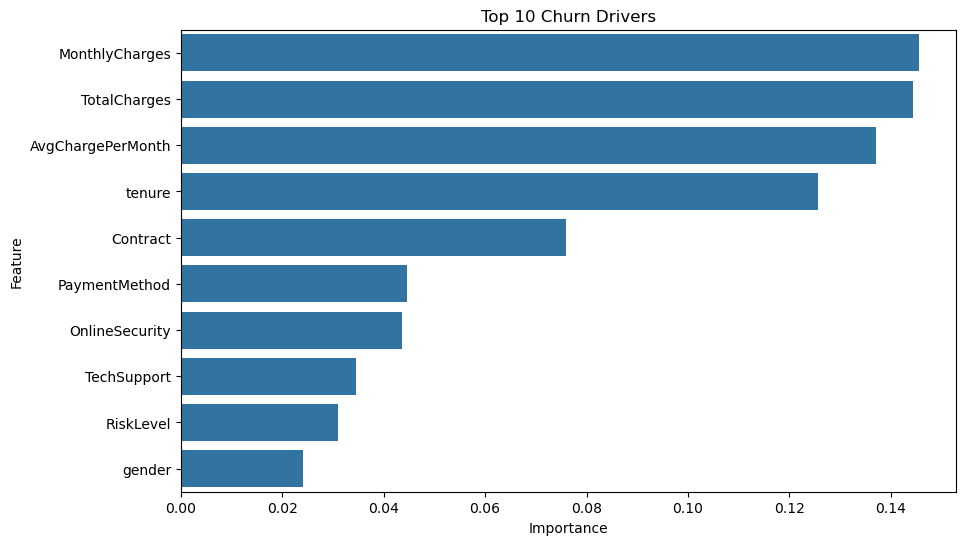

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Churn Drivers")

plt.show()

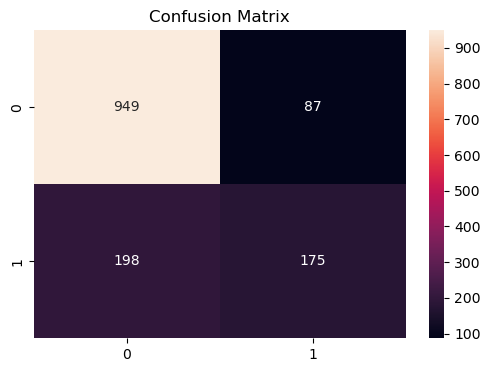

In [26]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

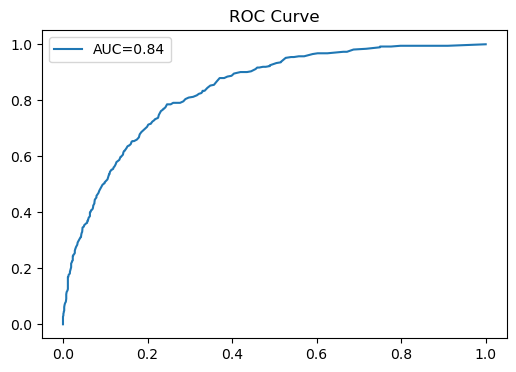

In [27]:
prob = rf.predict_proba(
    X_test
)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={roc_auc:.2f}"
)

plt.legend()

plt.title("ROC Curve")

plt.show()

In [28]:
print("Business Insights")

print(
    f"Average Monthly Charge: {df['MonthlyCharges'].mean():.2f}"
)

print(
    f"Average Tenure: {df['tenure'].mean():.2f}"
)

print(
    f"Churn Rate: {(df['Churn'].mean()*100):.2f}%"
)

Business Insights
Average Monthly Charge: 64.76
Average Tenure: 32.37
Churn Rate: 26.54%


In [29]:
joblib.dump(
    rf,
    "customer_churn_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [30]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AvgChargePerMonth', 'RiskLevel']


In [33]:
print(results.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.807665   0.668874  0.541555  0.598519
1        Decision Tree  0.801278   0.625337  0.621984  0.623656
2        Random Forest  0.797729   0.667939  0.469169  0.551181


In [34]:
print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [35]:
joblib.dump(rf, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [36]:
best_model = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

print("Best Model:", best_model)

Best Model: Logistic Regression


In [37]:
import joblib

joblib.dump(lr, "customer_churn_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [38]:
import os

print(os.path.exists("customer_churn_model.pkl"))

True


In [39]:
print(df.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
0              1                0               0             2  ...   
1              0                0               2             0  ...   
2              0                0               2             2  ...   
3              1                0               2             0  ...   
4              0                1               0             0  ...   

   StreamingTV  StreamingMovies  Contract  PaperlessBilling  PaymentMethod  \
0            0                0         0                 1   

In [46]:
import os

print(os.getcwd())

C:\Users\aashi


In [41]:
import os

print(os.path.abspath("WA_Fn-UseC_-Telco-Customer-Churn.csv"))

C:\Users\aashi\WA_Fn-UseC_-Telco-Customer-Churn.csv


In [42]:
import os
print(os.path.abspath("WA_Fn-UseC_-Telco-Customer-Churn.csv"))

C:\Users\aashi\WA_Fn-UseC_-Telco-Customer-Churn.csv


In [43]:
import os
print(os.path.abspath("WA_Fn-UseC_-Telco-Customer-Churn.csv"))

C:\Users\aashi\WA_Fn-UseC_-Telco-Customer-Churn.csv


In [44]:
import os
print(os.path.abspath("customer_churn_model.pkl"))

C:\Users\aashi\customer_churn_model.pkl


In [45]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'AvgChargePerMonth', 'RiskLevel']


In [51]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    if df[col].dtype != "object":
        continue

    le = LabelEncoder()
    le.fit(df[col])

    print("\n", col)
    print(dict(zip(le.classes_, le.transform(le.classes_))))